# ILUSTR 3 — Pivoting, a potem uwarunkowanie: LU vs QR, cond(A) jako predyktor błędu i jako elipsa

W ILUSTR2 pokazaliśmy, że rozłożenie macierzy na czynniki raz i wielokrotne, tanie podstawianie jest dużo tańsze niż rozwiązywanie układu od nowa za każdym razem — to ogólna idea **każdego** rozkładu (LU, QR, Cholesky, ...), nie tylko LU. Tutaj pytamy o coś innego: skoro różne rozkłady kosztują różnie (LU: ok. $\frac{2}{3}n^3$, QR metodą Householdera: ok. $\frac{4}{3}n^3$ — czyli około dwa razy drożej), to czy ta dodatkowa cena QR faktycznie kupuje coś w zamian? Ale zanim do tego dojdziemy, trzeba najpierw zobaczyć, **po co w ogóle jest pivoting** — bez niego sam algorytm, niezależnie od uwarunkowania macierzy, może dać kompletnie błędny wynik (Demo 1).

Sześć demonstracji:
1. **Pivoting — katastrofa bez wyboru elementu głównego, i ratunek** — ten sam poziom zaokrąglenia, inny wybór pivota, radykalnie inny wynik.
2. **LU vs QR — dokładność względem oszacowania teoretycznego** — porównujemy rzeczywisty błąd rozwiązania obiema metodami z klasycznym oszacowaniem teoretycznym $cond(A)\cdot\varepsilon_{maszyny}$, na macierzy, której $cond(A)$ *naprawdę* rośnie wraz z $n$.
3. **cond(A) jako predyktor błędu** — zestawiamy tę samą zależność dla dwóch zupełnie różnych rodzin macierzy i pokazujemy, że mimo to punkty układają się na tej samej linii $cond(A)\cdot\varepsilon_{maszyny}$.
4. **Tempo wzrostu cond(A) zależy od typu macierzy** — ten sam rozmiar $n$, zupełnie różne $cond(A)$: pokazujemy, że utrata precyzji jest nieunikniona przy wystarczająco dużym $n$, ale to, *jak szybko* do niej dochodzi, zależy od charakteru danych, nie tylko od rozmiaru układu.
5. **cond(A) jako elipsa** — pokazujemy geometrycznie, skąd bierze się liczba $cond(A)$: to stosunek długości półosi elipsy, na jaką macierz $A$ przekształca okrąg jednostkowy.
6. **Wpływ ΔA vs Δb na błąd rozwiązania** — który z dwóch źródeł błędu danych wejściowych (macierz czy wektor prawej strony) zwykle dominuje w praktyce, i dlaczego.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular, hilbert
from scipy.linalg import lu as lu_rozklad

EPS = np.finfo(np.float64).eps


def lehmer(n):
    # Macierz Lehmera: L[i,j] = min(i,j)/max(i,j) (indeksowanie od 1) --
    # symetryczna, dodatnio okreslona, cond(A) rosnie w przyblizeniu jak n^2
    i = np.arange(1, n + 1).reshape(-1, 1)
    j = np.arange(1, n + 1).reshape(1, -1)
    return np.minimum(i, j) / np.maximum(i, j)

def qr_householder_wlasny(A):
    # Wlasna, NIEBLOKOWANA implementacja QR metoda Householdera (jedno
    # odbicie na raz) -- uzywana zamiast wbudowanej np.linalg.qr, bo ta
    # powyzej pewnego rozmiaru przelacza sie w LAPACK na wersje blokowana,
    # co dorzucaloby do wynikow skokowy efekt niezwiazany z sama
    # matematyka porownania LU vs QR (patrz material opcjonalny).
    n = A.shape[0]
    Q = np.eye(n)
    R = A.copy()
    for k in range(n - 1):
        x = R[k:, k].copy()
        alpha = -np.sign(x[0]) * np.linalg.norm(x) if x[0] != 0 else -np.linalg.norm(x)
        v = x.copy()
        v[0] -= alpha
        vnorm = np.linalg.norm(v)
        if vnorm < 1e-300:
            continue
        v /= vnorm
        R[k:, k:] -= 2 * np.outer(v, v @ R[k:, k:])
        Q[k:, :] -= 2 * np.outer(v, v @ Q[k:, :])
    return Q.T, np.triu(R)



## Demo 1 — Pivoting: katastrofa bez wyboru elementu głównego, i ratunek

Mały, w pełni czytelny przykład 2×2:

$$
\begin{aligned}
0.0001\,x_1 + x_2 &= 1 \\
x_1 + x_2 &= 2
\end{aligned}
$$

Dokładne rozwiązanie: $x_1 = 1/0.9999 = 1.00010\ldots$, $x_2 = 0.9999\cdot x_1 = 0.99990\ldots$ — oba bardzo blisko 1.

Symulujemy tu ręcznie, co się dzieje, gdy **każdy krok eliminacji jest zaokrąglany do 3 cyfr znaczących** (tak jak w arytmetyce ograniczonej precyzji) — raz **bez** zamiany wierszy (pivot = najmniejszy możliwy element, $0.0001$), raz **z** zamianą wierszy (pivot = największy element w kolumnie, $1$).

In [2]:
def round_sig(x, n):
    # zaokraglenie do n cyfr znaczacych
    if x == 0:
        return 0.0
    d = n - int(np.floor(np.log10(abs(x)))) - 1
    return round(x, d)

SIG = 3
A0 = np.array([[0.0001, 1.0], [1.0, 1.0]])
b0 = np.array([1.0, 2.0])
x_dokladne = np.linalg.solve(A0, b0)
print(f'Rozwiazanie dokladne: x1={x_dokladne[0]:.5f}, x2={x_dokladne[1]:.5f}')

# --- Wariant A: BEZ pivotingu (pivot = 0.0001, mniejszy element w kolumnie) ---
m = A0[1, 0] / A0[0, 0]                        # mnoznik = 1/0.0001 = 10000
print('\n--- Bez pivotingu (pivot=0.0001) ---')
print(f'Mnoznik: {m:.1f}')
a22 = round_sig(A0[1, 1] - m * A0[0, 1], SIG)   # 1 - 10000*1 = -9999 -> zaokraglone
b2 = round_sig(b0[1] - m * b0[0], SIG)          # 2 - 10000*1 = -9998 -> zaokraglone
print(f'Po eliminacji (zaokraglone do {SIG} cyfr znaczacych): {a22:.0f}*x2 = {b2:.0f}')
x2_zly = b2 / a22
x1_zly = (b0[0] - A0[0, 1] * x2_zly) / A0[0, 0]
print(f'x2 = {x2_zly:.4f}')
print(f'x1 = ({b0[0]:.0f} - {A0[0,1]:.0f}*{x2_zly:.4f}) / {A0[0,0]:.4f} = {x1_zly:.4f}   <-- BLAD: powinno byc ~1.0')

# --- Wariant B: Z pivotingiem czesciowym (zamiana wierszy, pivot = 1) ---
A1 = A0[[1, 0], :]   # zamiana wierszy: teraz na diagonali jest najwiekszy element kolumny
b1 = b0[[1, 0]]
m2 = A1[1, 0] / A1[0, 0]                       # mnoznik = 0.0001/1 = 0.0001
print('\n--- Z pivotingiem (zamiana wierszy, pivot=1) ---')
print(f'Mnoznik: {m2:.4f}')
a22_p = round_sig(A1[1, 1] - m2 * A1[0, 1], SIG)
b2_p = round_sig(b1[1] - m2 * b1[0], SIG)
print(f'Po eliminacji (zaokraglone do {SIG} cyfr znaczacych): {a22_p:.4f}*x2 = {b2_p:.4f}')
x2_ok = b2_p / a22_p
x1_ok = (b1[0] - A1[0, 1] * x2_ok) / A1[0, 0]
print(f'x2 = {x2_ok:.4f}')
print(f'x1 = {x1_ok:.4f}   <-- POPRAWNIE, blisko dokladnego {x_dokladne[0]:.4f}')

print(f'\nBlad wzgledny x1 bez pivotingu: {100*abs(x1_zly - x_dokladne[0])/abs(x_dokladne[0]):.1f}%')
print(f'Blad wzgledny x1 z pivotingiem:  {100*abs(x1_ok - x_dokladne[0])/abs(x_dokladne[0]):.4f}%')

Rozwiazanie dokladne: x1=1.00010, x2=0.99990

--- Bez pivotingu (pivot=0.0001) ---
Mnoznik: 10000.0
Po eliminacji (zaokraglone do 3 cyfr znaczacych): -10000*x2 = -10000
x2 = 1.0000
x1 = (1 - 1*1.0000) / 0.0001 = 0.0000   <-- BLAD: powinno byc ~1.0

--- Z pivotingiem (zamiana wierszy, pivot=1) ---
Mnoznik: 0.0001
Po eliminacji (zaokraglone do 3 cyfr znaczacych): 1.0000*x2 = 1.0000
x2 = 1.0000
x1 = 1.0000   <-- POPRAWNIE, blisko dokladnego 1.0001

Blad wzgledny x1 bez pivotingu: 100.0%
Blad wzgledny x1 z pivotingiem:  0.0100%


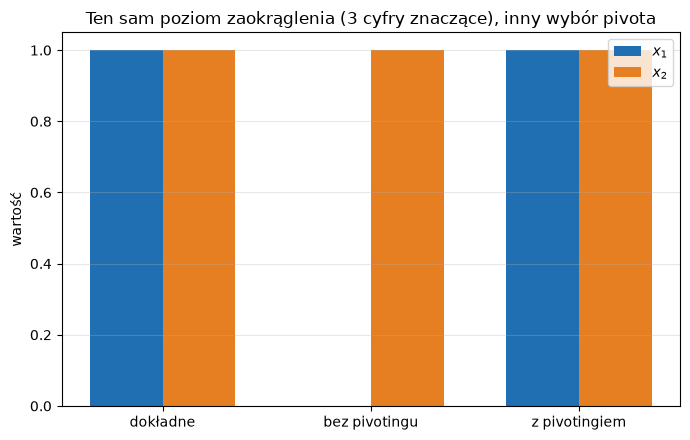

In [3]:
etykiety = ['dokładne', 'bez pivotingu', 'z pivotingiem']
x1_wartosci = [x_dokladne[0], x1_zly, x1_ok]
x2_wartosci = [x_dokladne[1], x2_zly, x2_ok]

x_pos = np.arange(len(etykiety))
width = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x_pos - width/2, x1_wartosci, width, label='$x_1$', color='#1f6fb2')
plt.bar(x_pos + width/2, x2_wartosci, width, label='$x_2$', color='#e67e22')
plt.xticks(x_pos, etykiety)
plt.ylabel('wartość')
plt.title('Ten sam poziom zaokrąglenia (3 cyfry znaczące), inny wybór pivota')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Dokładnie to samo zaokrąglenie (3 cyfry znaczące) na każdym kroku — jedyna różnica to **który element wybrano jako pivot**. Małe zaburzenie w mianowniku przy dzieleniu w podstawianiu wstecz zostaje wzmocnione tysiąckrotnie, bo dzielimy przez małą liczbę ($0.0001$).

**Zasada pivotingu częściowego**: przed eliminacją kolumny wybierz spośród pozostałych wierszy ten o największej wartości bezwzględnej w tej kolumnie i przestaw go na pozycję diagonalną. To domyślne zachowanie w każdej sensownej bibliotece numerycznej (m.in. `numpy.linalg.solve`, `scipy.linalg.lu`) — w kolejnych demo (2–5) zakładamy już, że pivoting jest włączony.

#### Ćwiczenie (Demo 1)
1. Spróbuj `SIG = 4` lub `SIG = 5` (więcej cyfr znaczących) w obu wariantach — od którego `SIG` wynik bez pivotingu przestaje być katastrofalnie zły? Dlaczego pivoting i tak pozostaje standardem, skoro w praktyce arytmetyka ma aż ~16 cyfr znaczących (`double`)?
2. Zamień $0.0001$ na jeszcze mniejszą wartość (np. $10^{-8}$) i sprawdź, czy błąd bez pivotingu rośnie jeszcze bardziej, czy zostaje podobny.

### Demo 1 — dopełnienie: mechanika macierzy permutacji P ($PA=LU$)

Przykład 2×2 wyżej pokazał **po co** jest pivoting. Zobaczmy teraz **jak** to się księgowo zapisuje przy pełnym rozkładzie LU większej macierzy — na tym samym przykładzie 3×3, co w konspekcie:

$$A = \begin{bmatrix}2&1&1\\4&3&3\\8&7&9\end{bmatrix}$$

Przy pivotingu częściowym **każda** zamiana wierszy macierzy roboczej musi być też zapisana w osobnej macierzy permutacji $P$ (startującej jako macierz jednostkowa) — tak, żeby na koniec zachodziło ściśle $PA=LU$, a nie tylko $A=LU$ (co dla tej macierzy w ogóle by się nie zgadzało bez pivotingu).

In [4]:
A_p = np.array([[2., 1., 1.], [4., 3., 3.], [8., 7., 9.]])
n_p = A_p.shape[0]
L_p = np.eye(n_p)
U_p = A_p.copy()
P_p = np.eye(n_p)

for k in range(n_p - 1):
    idx = np.argmax(np.abs(U_p[k:, k])) + k
    if idx != k:
        U_p[[k, idx], :] = U_p[[idx, k], :]
        P_p[[k, idx], :] = P_p[[idx, k], :]
        if k > 0:
            L_p[[k, idx], :k] = L_p[[idx, k], :k]   # juz zapisane mnozniki "wedruja" razem z wierszem
        print(f"Pivoting: zamiana wierszy {k+1} i {idx+1} (nowy pivot = {U_p[k, k]:.0f})")
    for i in range(k + 1, n_p):
        L_p[i, k] = U_p[i, k] / U_p[k, k]
        U_p[i, :] -= L_p[i, k] * U_p[k, :]

print("\nL =\n", L_p)
print("U =\n", U_p)
print("P =\n", P_p)
print(f"Sprawdzenie na konkretnych liczbach: max|P@A - L@U| = {np.max(np.abs(P_p @ A_p - L_p @ U_p)):.2e} (powinno być ~0)")

from scipy.linalg import lu as lu_ref
P_ref, L_ref, U_ref = lu_ref(A_p)   # scipy: A = P_ref @ L_ref @ U_ref, wiec P_ref.T odpowiada naszemu P_p
print(f"Zgodność z scipy.linalg.lu(): max|L-L_ref|={np.max(np.abs(L_p-L_ref)):.2e}, "
      f"max|U-U_ref|={np.max(np.abs(U_p-U_ref)):.2e}, max|P-P_ref.T|={np.max(np.abs(P_p-P_ref.T)):.2e}")

Pivoting: zamiana wierszy 1 i 3 (nowy pivot = 8)
Pivoting: zamiana wierszy 2 i 3 (nowy pivot = -1)

L =
 [[1.         0.         0.        ]
 [0.25       1.         0.        ]
 [0.5        0.66666667 1.        ]]
U =
 [[ 8.          7.          9.        ]
 [ 0.         -0.75       -1.25      ]
 [ 0.          0.         -0.66666667]]
P =
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
Sprawdzenie na konkretnych liczbach: max|P@A - L@U| = 0.00e+00 (powinno być ~0)
Zgodność z scipy.linalg.lu(): max|L-L_ref|=0.00e+00, max|U-U_ref|=2.22e-16, max|P-P_ref.T|=0.00e+00


Widać wprost: $P$ przestawia wiersze **oryginalnej** macierzy $A$ (tu: wiersz 3, potem 1, potem 2 — $PA = \begin{bmatrix}8&7&9\\2&1&1\\4&3&3\end{bmatrix}$) dokładnie w takiej kolejności, w jakiej pivoting przestawiał wiersze macierzy roboczej w trakcie eliminacji. To dlatego równanie $Ax=b$ trzeba w praktyce rozwiązywać jako $L(Ux)=Pb$ (przestawiając **też** prawą stronę $b$ tym samym $P$), a nie $LUx=b$ wprost.

## Demo 2: LU vs QR — dokładność względem oszacowania teoretycznego

Zarówno LU (z pivotingiem), jak i QR (metodą Householdera) to metody **numerycznie stabilne wstecznie** (ang. *backward stable*) — oznacza to, że obliczony wynik jest dokładnym rozwiązaniem układu z lekko zaburzoną macierzą $A+\Delta A$, gdzie $\|\Delta A\|$ jest rzędu $\varepsilon_{maszyny}$. Klasyczne oszacowanie teoretyczne mówi więc, że błąd względny rozwiązania obiema metodami powinien być rzędu

$$\frac{\|\Delta x\|}{\|x\|} \approx cond(A)\cdot\varepsilon_{maszyny}$$

**Uwaga na dobór macierzy testowej.** Gdyby $A$ było zwykłą losową macierzą Gaussa, $cond(A)$ rósłby wraz z $n$ tylko w przybliżeniu liniowo — nawet dla $n=1500$ pozostaje rzędu $10^3$–$10^4$, więc różnice między metodami są niemal niewidoczne na wykresie. Z drugiej strony słynna **macierz Hilberta** ($h_{i,j}=1/(i+j-1)$) jest tak ekstremalnie źle uwarunkowana, że staje się praktycznie osobliwa już przy $n\approx 13$ — to ciekawy przypadek brzegowy, ale nie reprezentuje typowej sytuacji inżynierskiej.

Używamy więc pośredniego przykładu: **macierzy Lehmera**, $L_{i,j}=\min(i,j)/\max(i,j)$ — klasycznej, umiarkowanie źle uwarunkowanej macierzy testowej, której $cond(A)$ rośnie w przybliżeniu jak $n^2$ (bez katastrofalnego załamania). Sprawdzamy empirycznie: dla rosnącego rozmiaru $n$ budujemy układ ze znanym z góry dokładnym rozwiązaniem $x_{prawdziwe}$, rozwiązujemy go **obiema metodami na tych samych danych** i porównujemy oba błędy z $cond(A)\cdot\varepsilon_{maszyny}$.

Do części QR używamy **własnej**, prostej implementacji metody Householdera (funkcja `qr_householder_wlasny` powyżej), a **nie** wbudowanej `np.linalg.qr`. Powód: wbudowana funkcja powyżej pewnego rozmiaru macierzy automatycznie przełącza się w bibliotece LAPACK na inny (blokowany) wariant algorytmu, co dorzucałoby do poniższego wykresu dodatkowy, skokowy efekt niezwiązany z samą matematyką porównania LU vs QR. Ten szczegół biblioteczny jest ciekawy, ale wykracza poza podstawowy kurs — kto jest zainteresowany, znajdzie go w materiale **opcjonalnym**: `Optional stuff/ZI_R_LIN_ILUSTR3_QR_LAPACK_OPTIONAL_PYTHON.ipynb` / `.m`.


In [5]:
def rozwiaz_i_zmierz(n, rng):
    A = lehmer(n)
    x_prawdziwe = rng.standard_normal(n)
    b = A @ x_prawdziwe

    x_lu = np.linalg.solve(A, b)                       # LU z pivotingiem (LAPACK dgesv)
    Q, R = qr_householder_wlasny(A)                      # QR metoda Householdera (wlasna)
    x_qr = solve_triangular(R, Q.T @ b)

    blad_lu = np.linalg.norm(x_lu - x_prawdziwe) / np.linalg.norm(x_prawdziwe)
    blad_qr = np.linalg.norm(x_qr - x_prawdziwe) / np.linalg.norm(x_prawdziwe)
    oszacowanie_teoretyczne = np.linalg.cond(A) * EPS

    # reszta ||Ax-b||/(||A|| ||x||) -- blad wsteczny, NIEZALEZNY od cond(A)
    # (w przeciwienstwie do bledu wzgledem x_prawdziwe powyzej)
    reszta_lu = np.linalg.norm(A @ x_lu - b) / (np.linalg.norm(A) * np.linalg.norm(x_lu))
    reszta_qr = np.linalg.norm(A @ x_qr - b) / (np.linalg.norm(A) * np.linalg.norm(x_qr))

    return blad_lu, blad_qr, oszacowanie_teoretyczne, reszta_lu, reszta_qr


rozmiary = np.unique(np.round(np.logspace(np.log10(5), np.log10(1000), 16)).astype(int))
POWTORZENIA = 5   # kilka losowych x_prawdziwe na kazdy rozmiar -- mediana usuwa "pechowy" kierunek

bledy_lu = np.empty(len(rozmiary))
bledy_qr = np.empty(len(rozmiary))
teoretyczne = np.empty(len(rozmiary))
reszty_lu = np.empty(len(rozmiary))
reszty_qr = np.empty(len(rozmiary))

for k, n in enumerate(rozmiary):
    rng = np.random.default_rng(int(n))
    wyniki = [rozwiaz_i_zmierz(n, rng) for _ in range(POWTORZENIA)]
    bledy_lu[k] = np.median([w[0] for w in wyniki])
    bledy_qr[k] = np.median([w[1] for w in wyniki])
    teoretyczne[k] = np.median([w[2] for w in wyniki])
    reszty_lu[k] = np.median([w[3] for w in wyniki])
    reszty_qr[k] = np.median([w[4] for w in wyniki])
    print(f"n={n:5d}   LU: {bledy_lu[k]:.2e}   QR: {bledy_qr[k]:.2e}   teoretyczne: {teoretyczne[k]:.2e}   reszta QR/LU: {reszty_qr[k]/reszty_lu[k]:.2f}")


n=    5   LU: 4.66e-16   QR: 4.05e-16   teoretyczne: 4.36e-15   reszta QR/LU: 3.22
n=    7   LU: 9.33e-16   QR: 2.21e-15   teoretyczne: 8.97e-15   reszta QR/LU: 2.53
n=   10   LU: 1.38e-15   QR: 2.34e-15   teoretyczne: 1.92e-14   reszta QR/LU: 1.61
n=   14   LU: 3.34e-15   QR: 5.63e-15   teoretyczne: 3.91e-14   reszta QR/LU: 1.83
n=   21   LU: 6.50e-15   QR: 9.01e-15   teoretyczne: 9.16e-14   reszta QR/LU: 1.79
n=   29   LU: 7.54e-15   QR: 1.46e-14   teoretyczne: 1.79e-13   reszta QR/LU: 1.89
n=   42   LU: 2.17e-14   QR: 2.77e-14   teoretyczne: 3.86e-13   reszta QR/LU: 1.89
n=   59   LU: 3.79e-14   QR: 5.69e-14   teoretyczne: 7.76e-13   reszta QR/LU: 2.76
n=   84   LU: 8.49e-14   QR: 1.22e-13   teoretyczne: 1.60e-12   reszta QR/LU: 2.27


n=  120   LU: 1.20e-13   QR: 2.39e-13   teoretyczne: 3.30e-12   reszta QR/LU: 2.32


n=  171   LU: 2.04e-13   QR: 5.66e-13   teoretyczne: 6.78e-12   reszta QR/LU: 2.41


n=  243   LU: 5.34e-13   QR: 9.02e-13   teoretyczne: 1.38e-11   reszta QR/LU: 2.41


n=  347   LU: 1.04e-12   QR: 2.55e-12   teoretyczne: 2.84e-11   reszta QR/LU: 3.48


n=  493   LU: 2.55e-12   QR: 6.26e-12   teoretyczne: 5.75e-11   reszta QR/LU: 3.32


n=  702   LU: 3.42e-12   QR: 9.75e-12   teoretyczne: 1.17e-10   reszta QR/LU: 4.54


n= 1000   LU: 6.14e-12   QR: 2.12e-11   teoretyczne: 2.39e-10   reszta QR/LU: 6.19


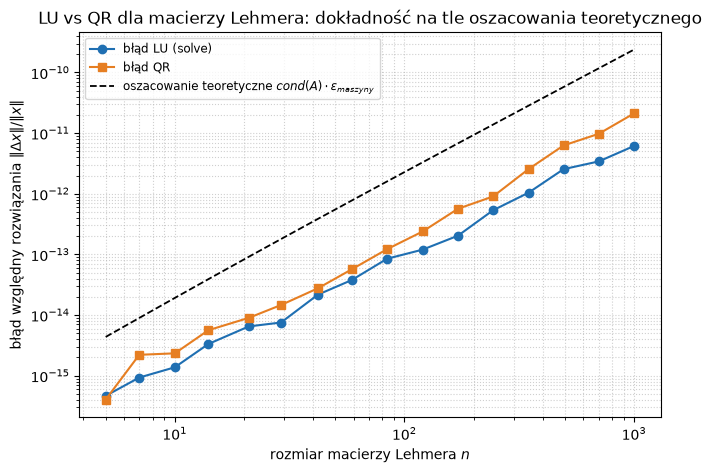

In [6]:
plt.figure(figsize=(7.5, 5))
plt.loglog(rozmiary, bledy_lu, 'o-', color='#1f6fb2', label='błąd LU (solve)')
plt.loglog(rozmiary, bledy_qr, 's-', color='#e67e22', label='błąd QR')
plt.loglog(rozmiary, teoretyczne, '--', color='black', linewidth=1.3,
           label=r'oszacowanie teoretyczne $cond(A)\cdot\varepsilon_{maszyny}$')
plt.xlabel(r'rozmiar macierzy Lehmera $n$')
plt.ylabel(r'błąd względny rozwiązania $\|\Delta x\|/\|x\|$')
plt.title('LU vs QR dla macierzy Lehmera: dokładność na tle oszacowania teoretycznego')
plt.legend(fontsize=8.5)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()


Obie metody pozostają w tym samym rzędzie co oszacowanie teoretyczne $cond(A)\cdot\varepsilon_{maszyny}$ na przestrzeni kilku rzędów wielkości błędu (od $n=5$ do $n=1000$), i to bez żadnego załamania — inaczej niż dla macierzy Hilberta, gdzie już przy $n\approx13$ obie metody by się kompletnie posypały. To znaczy, że o osiągalnej dokładności rozwiązania decyduje **przede wszystkim uwarunkowanie samej macierzy $A$**, a nie wybór metody rozkładu.

Przyjrzyjmy się jednak dokładniej wykresowi (i kolumnie "reszta QR/LU" wypisanej wyżej): LU jest konsekwentnie **dokładniejsze** od QR, a różnica rośnie łagodnie z $n$ — od ok. 1.6-2x przy małych/średnich $n$ do ok. 6x przy $n=1000$. To prawdziwy, choć niewielki efekt matematyczny: rozwiązanie przez QR wymaga, oprócz samego rozkładu, dodatkowego mnożenia $Q^Tb$, a każdy dodatkowy krok arytmetyczny dorzuca swoją małą porcję błędu zaokrąglenia — podczas gdy LU kończy się od razu podstawieniem trójkątnym.

Wniosek pozostaje: dodatkowy koszt QR (patrz ILUSTR2) nie kupuje lepszej dokładności dla zwykłego układu kwadratowego — w praktyce daje wynik nieco gorszy. QR wybiera się z innych powodów: gwarantowanej stabilności bez pivotingu, albo do zadań, których LU w ogóle nie rozwiązuje (układy prostokątne, zadanie najmniejszych kwadratów, macierze bliskie osobliwym).


To **nie** znaczy, że QR nie ma realnej przewagi nad LU — znaczy tylko, że macierz Lehmera nie jest odpowiednim przykładem, żeby ją zobaczyć. Pełne (nie uproszczone) oszacowanie błędu ma bowiem postać

$$\frac{\|\Delta x\|}{\|x\|} \approx cond(A)\cdot\rho_n\cdot\varepsilon_{maszyny}$$

gdzie $\rho_n$ to **czynnik wzrostu** (*growth factor*) eliminacji Gaussa — stosunek największej wartości, jaka pojawi się w macierzy $U$ w trakcie eliminacji, do największej wartości w oryginalnej macierzy $A$. Mierzy on, jak bardzo **sam algorytm** (a nie uwarunkowanie problemu) powiększa liczby w trakcie obliczeń — a większe liczby po drodze oznaczają większe błędy zaokrąglenia przy każdym kolejnym kroku. Dla LU z pivotingiem częściowym $\rho_n$ zależy od **konkretnej** macierzy: dla macierzy symetrycznych dodatnio określonych (jak Lehmera) jest **dowiedzione**, że $\rho_n=1$ zawsze — LU działa tam w swoim najlepszym możliwym trybie, więc QR nie ma nic do "uratowania". Dla QR (Householder) $\rho_n$ jest ograniczone wielomianowo w $n$, **niezależnie od macierzy** — to właśnie ta gwarancja stoi za podręcznikowym stwierdzeniem "QR jest stabilniejsze od LU".

Zobaczmy to na macierzy zaprojektowanej specjalnie tak, żeby wystawić na próbę stabilność LU: same jedynki na diagonali i w ostatniej kolumnie, $-1$ poniżej diagonali. Pivoting **nie** zamienia tu żadnych wierszy (element na diagonali jest już największy co do wartości bezwzględnej w swojej kolumnie), ale mimo to wartości w kolejnych kolumnach **podwajają się** przy każdym kroku eliminacji — co daje $\rho_n = 2^{n-1}$, rosnące **wykładniczo** z $n$. Kluczowe: $cond(A)$ tej macierzy pozostaje przy tym **małe** (rzędu kilkudziesięciu nawet dla $n=60$) — to **nie** jest macierz źle uwarunkowana w sensie $cond(A)$. To czysty test na to, czy sam algorytm (a nie problem) psuje dokładność.


In [7]:
def macierz_adwersarialna(n):
    # Macierz "adwersarialna" dla LU z pivotingiem czesciowym: jedynki na
    # diagonali i w ostatniej kolumnie, -1 ponizej diagonali. Zaden pivot
    # nigdy nie wymaga zamiany wierszy (diagonala jest juz maksimum w
    # kolumnie), ale mimo to wartosci w U rosna jak 2^(n-1) -- klasyczny
    # przyklad macierzy o zlym growth factor przy dobrym cond(A).
    A = -np.tril(np.ones((n, n)), -1)
    np.fill_diagonal(A, 1.0)
    A[:, -1] = 1.0
    return A


rozmiary_adw = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 53, 56, 58, 60]

bledy_lu_adw = np.empty(len(rozmiary_adw))
bledy_qr_adw = np.empty(len(rozmiary_adw))
rho_adw = np.empty(len(rozmiary_adw))
cond_adw = np.empty(len(rozmiary_adw))

for k, n in enumerate(rozmiary_adw):
    A = macierz_adwersarialna(n)
    rng = np.random.default_rng(n)
    x_prawdziwe = rng.standard_normal(n)
    b = A @ x_prawdziwe

    x_lu = np.linalg.solve(A, b)                        # LU z pivotingiem
    Q, R = qr_householder_wlasny(A)                      # QR metoda Householdera (wlasna)
    x_qr = solve_triangular(R, Q.T @ b)

    bledy_lu_adw[k] = np.linalg.norm(x_lu - x_prawdziwe) / np.linalg.norm(x_prawdziwe)
    bledy_qr_adw[k] = np.linalg.norm(x_qr - x_prawdziwe) / np.linalg.norm(x_prawdziwe)
    _, _, U = lu_rozklad(A)
    rho_adw[k] = np.max(np.abs(U)) / np.max(np.abs(A))
    cond_adw[k] = np.linalg.cond(A)

    print(f"n={n:3d}   LU: {bledy_lu_adw[k]:.2e}   QR: {bledy_qr_adw[k]:.2e}   rho_n: {rho_adw[k]:.3e}   cond(A): {cond_adw[k]:.2f}")


n=  5   LU: 2.64e-16   QR: 4.39e-16   rho_n: 1.600e+01   cond(A): 2.22
n= 10   LU: 4.92e-15   QR: 4.02e-16   rho_n: 5.120e+02   cond(A): 4.38
n= 15   LU: 2.55e-14   QR: 4.42e-16   rho_n: 1.638e+04   cond(A): 6.60
n= 20   LU: 9.01e-13   QR: 4.99e-16   rho_n: 5.243e+05   cond(A): 8.83
n= 25   LU: 2.63e-12   QR: 7.76e-16   rho_n: 1.678e+07   cond(A): 11.07
n= 30   LU: 1.28e-09   QR: 2.03e-15   rho_n: 5.369e+08   cond(A): 13.32
n= 35   LU: 4.32e-08   QR: 8.32e-16   rho_n: 1.718e+10   cond(A): 15.56
n= 40   LU: 5.32e-07   QR: 2.93e-15   rho_n: 5.498e+11   cond(A): 17.81
n= 45   LU: 9.17e-05   QR: 2.66e-15   rho_n: 1.759e+13   cond(A): 20.06
n= 50   LU: 3.60e-03   QR: 1.56e-15   rho_n: 5.629e+14   cond(A): 22.31
n= 53   LU: 3.81e-03   QR: 1.14e-15   rho_n: 4.504e+15   cond(A): 23.65
n= 56   LU: 9.32e-02   QR: 2.19e-15   rho_n: 3.603e+16   cond(A): 25.00
n= 58   LU: 2.85e-01   QR: 4.98e-15   rho_n: 1.441e+17   cond(A): 25.90
n= 60   LU: 2.32e-01   QR: 2.29e-15   rho_n: 5.765e+17   cond(A): 26

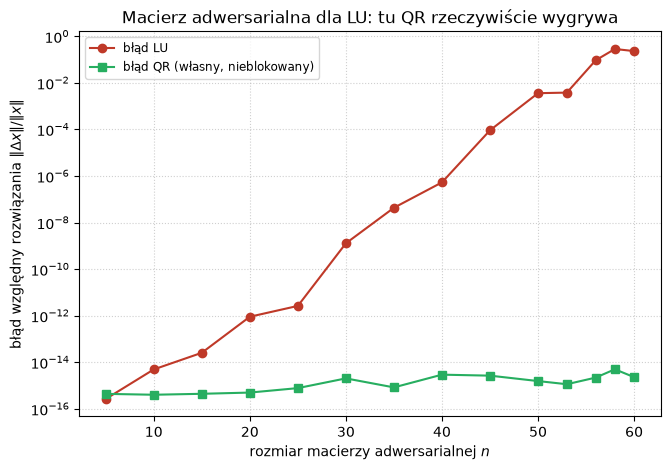

In [8]:
plt.figure(figsize=(7.5, 5))
plt.semilogy(rozmiary_adw, bledy_lu_adw, 'o-', color='#bf3928', label='błąd LU')
plt.semilogy(rozmiary_adw, bledy_qr_adw, 's-', color='#27ae60', label='błąd QR (własny, nieblokowany)')
plt.xlabel(r'rozmiar macierzy adwersarialnej $n$')
plt.ylabel(r'błąd względny rozwiązania $\|\Delta x\|/\|x\|$')
plt.title('Macierz adwersarialna dla LU: tu QR rzeczywiście wygrywa')
plt.legend(fontsize=8.5)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()


Widać dramatyczną różnicę: błąd LU rośnie **wykładniczo** z $n$ (od rzędu precyzji maszynowej przy $n=5$ do całkowitej bezużyteczności — błąd względny $>1$, czyli wynik nie ma nic wspólnego z prawdą — już przy $n\approx55$-$60$), podczas gdy błąd QR pozostaje cały czas na poziomie precyzji maszynowej, **niezależnie** od $n$. A jednocześnie $cond(A)$ tej macierzy przez cały ten zakres rośnie tylko z ok. 2 do ok. 27 (patrz kolumna `cond(A)` powyżej) — wiele rzędów wielkości **mniej** niż eksplozja błędu LU. To dowód nie do obalenia: to, co tu zawiodło, to nie uwarunkowanie problemu ($cond(A)$ pozostał mały), tylko **sam algorytm LU** — jego $\rho_n$ eksplodowało wykładniczo. QR, dzięki gwarantowanemu ograniczeniu $\rho_n$ niezależnie od macierzy, nie ma tego problemu.

To właśnie jest realna, podręcznikowa przewaga QR nad LU — ale pokazuje się ona na macierzach **adwersarialnych** dla pivotingu częściowego (rzadkich w typowej praktyce inżynierskiej, ale możliwych), nie na typowych, "naturalnie" źle uwarunkowanych macierzach jak Lehmera. Wniosek praktyczny: złe uwarunkowanie (duże $cond(A)$) i podatność na błąd algorytmu (duże $\rho_n$) to **dwie różne** rzeczy — LU jest wrażliwe na obie, QR tylko na pierwszą z nich.


Ale czy to nie jest tylko cecha akurat macierzy Lehmera? Sprawdźmy, czy ta sama zależność $\text{błąd}\approx cond(A)\cdot\varepsilon_{maszyny}$ trzyma się także dla zupełnie innej rodziny macierzy.

Sprawdzenie na boku: „odwrócenie Q za darmo” ($Q^T=Q^{-1}$), wykorzystane powyżej (`solve_triangular(R, Q.T @ b)` zamiast `solve_triangular(R, np.linalg.inv(Q) @ b)`), nie jest tylko skrótem zapisu — to ścisła własność macierzy ortogonalnej, bez żadnego błędu numerycznego (w przeciwieństwie do odwracania zwykłej macierzy).

In [9]:
Q_check, _ = qr_householder_wlasny(macierz_adwersarialna(20))
print(f"Sprawdzenie Q'=Q^-1 (n=20): max|Q'@Q - I| = {np.max(np.abs(Q_check.T @ Q_check - np.eye(20))):.2e}")

Sprawdzenie Q'=Q^-1 (n=20): max|Q'@Q - I| = 2.89e-15


## Demo 3: cond(A) jako predyktor błędu

W Demo 2 zmienialiśmy rozmiar $n$ tej samej rodziny macierzy (Lehmera) i patrzyliśmy, jak rosną razem $cond(A)$ i błąd. Postawmy pytanie inaczej: czy $cond(A)$ **samo w sobie**, niezależnie od tego, skąd pochodzi macierz i jakiego jest rozmiaru, przewiduje osiągalną dokładność?

Zestawiamy na jednym wykresie zmierzony błąd rozwiązania (metodą LU) w funkcji zmierzonego $cond(A)$ dla dwóch zupełnie różnych rodzin macierzy:
- **macierze losowe Gaussa** rosnącego rozmiaru $n$ — dobrze uwarunkowane, $cond(A)$ rośnie tylko powoli,
- **macierze Lehmera** z Demo 2 — umiarkowanie źle uwarunkowane, $cond(A)$ rośnie znacznie szybciej z $n$.

**Uwaga na oszacowanie teoretyczne.** Uproszczony wzór $cond(A)\cdot\varepsilon_{maszyny}$ pomija stałą zwaną *growth factor* ($\rho_n$), która zależy od **struktury** macierzy, nie tylko od wartości jej $cond(A)$ — więc nie ma jednego uniwersalnego oszacowania trafnego dla wszystkich macierzy naraz. Liczymy więc $\rho_n$ osobno dla każdej rodziny i porównujemy każdą z jej **własnym**, pełnym oszacowaniem $cond(A)\cdot\rho_n\cdot\varepsilon_{maszyny}$ — zamiast jednej wspólnej linii, która mogłaby błędnie sugerować, że dobrze uwarunkowana macierz losowa ma z jakiegoś powodu *większy* błąd niż gorzej uwarunkowana macierz Lehmera.


In [10]:
from scipy.linalg import lu as lu_rozklad


def growth_factor(A):
    _, _, U = lu_rozklad(A)
    return np.max(np.abs(U)) / np.max(np.abs(A))


def blad_lu_losowa(n, rng):
    A = rng.standard_normal((n, n))
    x_prawdziwe = rng.standard_normal(n)
    b = A @ x_prawdziwe
    x_lu = np.linalg.solve(A, b)
    blad = np.linalg.norm(x_lu - x_prawdziwe) / np.linalg.norm(x_prawdziwe)
    return np.linalg.cond(A), blad, growth_factor(A)


rozmiary_losowe = np.unique(np.round(np.logspace(np.log10(5), np.log10(1500), 15)).astype(int))
cond_losowe = np.empty(len(rozmiary_losowe))
blad_losowe = np.empty(len(rozmiary_losowe))
rho_losowe = np.empty(len(rozmiary_losowe))

for k, n in enumerate(rozmiary_losowe):
    rng = np.random.default_rng(int(n))
    wyniki = [blad_lu_losowa(n, rng) for _ in range(5)]
    cond_losowe[k] = np.median([w[0] for w in wyniki])
    blad_losowe[k] = np.median([w[1] for w in wyniki])
    rho_losowe[k] = np.median([w[2] for w in wyniki])

# Macierze Lehmera juz mamy policzone w Demo 2 -- odzyskujemy cond(A) z oszacowania teoretycznego.
# Growth factor Lehmera jest scisle rowny 1 (macierz symetryczna dodatnio
# okreslona) -- dowod klasyczny, wiec nie trzeba go liczyc numerycznie.
cond_lehmera = teoretyczne / EPS
blad_lehmera = bledy_lu
rho_lehmera = np.ones_like(cond_lehmera)


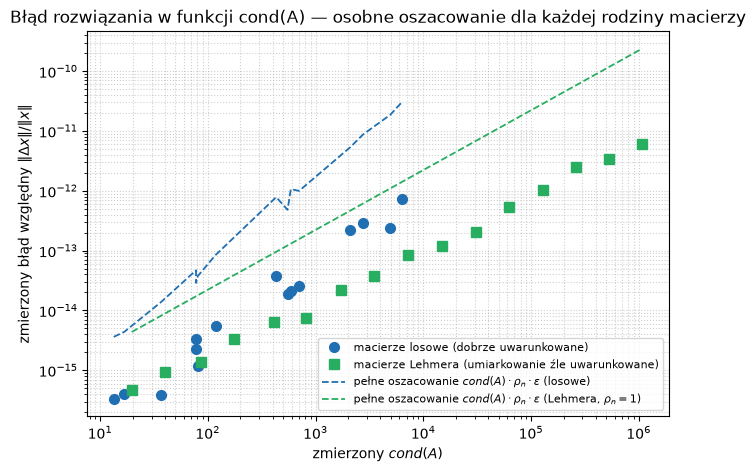

In [11]:
plt.figure(figsize=(7.5, 5))
plt.loglog(cond_losowe, blad_losowe, 'o', color='#1f6fb2', markersize=7,
           label='macierze losowe (dobrze uwarunkowane)')
plt.loglog(cond_lehmera, blad_lehmera, 's', color='#27ae60', markersize=7,
           label='macierze Lehmera (umiarkowanie źle uwarunkowane)')

idx_losowe = np.argsort(cond_losowe)
plt.loglog(cond_losowe[idx_losowe], (cond_losowe * rho_losowe * EPS)[idx_losowe],
           '--', color='#1f6fb2', linewidth=1.3,
           label=r'pełne oszacowanie $cond(A)\cdot\rho_n\cdot\varepsilon$ (losowe)')
idx_lehmera = np.argsort(cond_lehmera)
plt.loglog(cond_lehmera[idx_lehmera], (cond_lehmera * rho_lehmera * EPS)[idx_lehmera],
           '--', color='#27ae60', linewidth=1.3,
           label=r'pełne oszacowanie $cond(A)\cdot\rho_n\cdot\varepsilon$ (Lehmera, $\rho_n=1$)')

plt.xlabel(r'zmierzony $cond(A)$')
plt.ylabel(r'zmierzony błąd względny $\|\Delta x\|/\|x\|$')
plt.title('Błąd rozwiązania w funkcji cond(A) — osobne oszacowanie dla każdej rodziny macierzy')
plt.legend(fontsize=8)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.show()


Widać: obie rodziny — mimo że pochodzą z zupełnie innych macierzy i rozmiarów — leżą blisko swojej **własnej** linii odniesienia, w granicach jednego-dwóch rzędów wielkości. To wciąż praktyczna moc tego oszacowania: $cond(A)$ da się policzyć (albo tanio oszacować, np. przez `rcond`) bez znajomości dokładnego rozwiązania i bez rozwiązywania układu wieloma metodami naraz — a mimo to z góry mówi, ile cyfr znaczących wyniku możemy w przybliżeniu ufać. To dlatego $cond(A)$ jest standardowo raportowanym parametrem w bibliotekach numerycznych (np. ostrzeżenie „matrix is close to singular” w MATLAB/NumPy) — to nie ciekawostka teoretyczna, tylko praktyczny sygnał ostrzegawczy.

Zwróćmy jednak uwagę: to **nie** jest jedna wspólna prosta dla obu rodzin, tylko dwie osobne — bo pełne oszacowanie ma postać $cond(A)\cdot\rho_n\cdot\varepsilon_{maszyny}$, a $\rho_n$ (tzw. *growth factor* eliminacji Gaussa — stosunek największej wartości bezwzględnej w $U$ do największej w $A$) zależy od **struktury** macierzy, nie tylko od jej $cond(A)$:
- macierze Lehmera są **symetryczne dodatnio określone** — a dla tej klasy istnieje ścisły, udowodniony wynik: $\rho_n=1$ dokładnie, niezależnie od $n$. Ich linia odniesienia pokrywa się więc z uproszczonym $cond(A)\cdot\varepsilon_{maszyny}$.
- macierze losowe Gaussa nie mają takiej gwarancji — $\rho_n$ rośnie (łagodnie) z $n$, patrz dokładne liczby niżej. Ich linia odniesienia leży więc odrobinę **wyżej** niż uproszczony $cond(A)\cdot\varepsilon_{maszyny}$.

Gdybyśmy — jak w pierwszej, uproszczonej wersji tego wykresu — użyli **jednej** linii $cond(A)\cdot\varepsilon_{maszyny}$ dla obu rodzin naraz, punkty macierzy losowych wypadłyby bliżej tej wspólnej linii niż punkty macierzy Lehmera przy podobnym $cond(A)$, co mogłoby błędnie sugerować, że lepiej uwarunkowana macierz losowa ma relatywnie *gorszy* wynik niż gorzej uwarunkowana macierz Lehmera. To nieporozumienie brałoby się z porównywania obu rodzin do niewłaściwego (uproszczonego, jednego dla wszystkich) wzoru — a nie z jakiejś rzeczywistej, gorszej własności dobrze uwarunkowanych macierzy. Prawidłowo porównane — każda do swojej własnej, pełnej linii — obie rodziny zachowują się spójnie z teorią.


In [12]:
# Dokladne liczby stojace za powyzszymi dwiema liniami odniesienia -- rho_n
# dla obu rodzin, w szerszym zakresie n (do 2000, poza zasieg powyzszego
# wykresu, ktory dla macierzy losowych siega tylko do n=1500).
rozmiary_wzrostu = [10, 50, 100, 300, 600, 1000, 1500, 2000]
print(f"{'n':>6}  {'rho_n (losowa)':>15}  {'rho_n (Lehmera)':>16}")
for n in rozmiary_wzrostu:
    rng = np.random.default_rng(n)
    g_losowa = np.median([growth_factor(rng.standard_normal((n, n))) for _ in range(5)])
    g_lehmera = growth_factor(lehmer(n))
    print(f"{n:6d}  {g_losowa:15.2f}  {g_lehmera:16.2f}")


     n   rho_n (losowa)   rho_n (Lehmera)
    10             1.62              1.00
    50             2.96              1.00
   100             6.76              1.00
   300             8.86              1.00


   600            14.27              1.00


  1000            15.09              1.00


  1500            21.53              1.00


  2000            22.65              1.00


Widać: $\rho_n=1.00$ dla macierzy Lehmera przy **każdym** $n$ (co do cyfry) — dokładnie tak, jak przewiduje twierdzenie o macierzach symetrycznych dodatnio określonych. Dla macierzy losowych $\rho_n$ rośnie łagodnie z $n$ (od ok. $1.6$ przy $n=10$ do ok. $23$ przy $n=2000$ — *average case*, wynik Trefethena i Schreibera z 1990 r.) — stąd ich linia odniesienia leży odrobinę wyżej, ale wciąż w tym samym rzędzie wielkości.

**Wniosek praktyczny:** $cond(A)$ to świetny predyktor *rzędu wielkości* osiągalnej dokładności, ale nie jest to wzór ścisły co do stałej — ta stała ($\rho_n$) zależy od struktury macierzy (konkretnie: jak eliminacja Gaussa z pivotingiem radzi sobie akurat z tą macierzą), nie tylko od wartości samego $cond(A)$. Dlatego nie ma jednego uniwersalnego oszacowania $cond(A)\cdot\varepsilon_{maszyny}$ dla wszystkich macierzy naraz — trzeba je liczyć osobno dla każdej rodziny/struktury danych. To kolejny sygnał, że o osiągalnej precyzji decyduje nie tylko rozmiar układu, ale i charakter danych — dokładnie to, co badamy dalej w Demo 4.

Zauważmy też, że macierze losowe i macierze Lehmera osiągnęły w naszych eksperymentach bardzo różne wartości $cond(A)$ dla **tego samego** $n$ — a macierz Hilberta z opisu Demo 2 przy $n\approx 13$ ma $cond(A)$ rzędu $10^{18}$, czyli więcej niż wszystkie powyższe punkty razem wzięte. Skąd ta ogromna różnica w tempie wzrostu?


## Demo 4: tempo wzrostu cond(A) zależy od typu macierzy

Precyzja rozwiązania musi się w końcu zepsuć wraz z rosnącym $n$ — to nieunikniona konsekwencja tego, że $cond(A)$ rośnie. Pytanie praktyczne brzmi jednak: **jak szybko**? Odpowiedź zależy nie tylko od rozmiaru układu, ale przede wszystkim od tego, *jakie dane* i *jaką strukturę* ma macierz $A$.

Porównujemy $cond(A)$ w funkcji $n$ dla trzech rodzin macierzy tego samego (niewielkiego) rozmiaru:
- macierz losowa Gaussa — $cond(A)$ rośnie bardzo wolno,
- macierz Lehmera — $cond(A)$ rośnie wielomianowo (jak $n^2$),
- macierz Hilberta — $cond(A)$ rośnie wykładniczo.


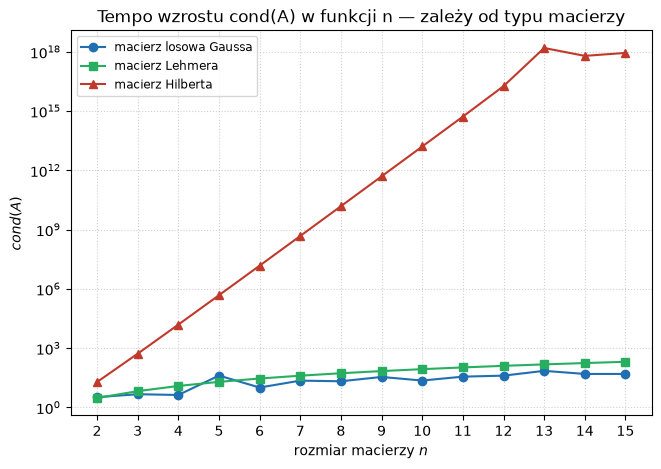

n= 2   losowa:       3.31   Lehmera:         3.00   Hilberta: 1.928e+01
n= 3   losowa:       4.66   Lehmera:         6.66   Hilberta: 5.241e+02
n= 4   losowa:       4.27   Lehmera:        12.21   Hilberta: 1.551e+04
n= 5   losowa:      40.80   Lehmera:        19.66   Hilberta: 4.766e+05
n= 6   losowa:      10.18   Lehmera:        29.04   Hilberta: 1.495e+07
n= 7   losowa:      22.68   Lehmera:        40.39   Hilberta: 4.754e+08
n= 8   losowa:      21.08   Lehmera:        53.72   Hilberta: 1.526e+10
n= 9   losowa:      34.80   Lehmera:        69.05   Hilberta: 4.932e+11
n=10   losowa:      22.93   Lehmera:        86.39   Hilberta: 1.602e+13
n=11   losowa:      36.06   Lehmera:       105.76   Hilberta: 5.227e+14
n=12   losowa:      40.59   Lehmera:       127.16   Hilberta: 1.808e+16
n=13   losowa:      70.96   Lehmera:       150.60   Hilberta: 1.548e+18
n=14   losowa:      49.46   Lehmera:       176.10   Hilberta: 6.184e+17
n=15   losowa:      49.41   Lehmera:       203.64   Hilberta: 8.

In [13]:
rozmiary_mala = np.arange(2, 16)

cond_losowe_mala = np.empty(len(rozmiary_mala))
cond_lehmera_mala = np.empty(len(rozmiary_mala))
cond_vander_mala = np.empty(len(rozmiary_mala))
cond_hilberta_mala = np.empty(len(rozmiary_mala))

for k, n in enumerate(rozmiary_mala):
    rng = np.random.default_rng(int(n))
    cond_losowe_mala[k] = np.median([np.linalg.cond(rng.standard_normal((n, n))) for _ in range(9)])
    cond_lehmera_mala[k] = np.linalg.cond(lehmer(n))
    cond_vander_mala[k] = np.linalg.cond(np.vander(np.linspace(0, 1, n)))
    cond_hilberta_mala[k] = np.linalg.cond(hilbert(n))

plt.figure(figsize=(7.5, 5))
plt.semilogy(rozmiary_mala, cond_losowe_mala, 'o-', color='#1f6fb2', label='macierz losowa Gaussa')
plt.semilogy(rozmiary_mala, cond_lehmera_mala, 's-', color='#27ae60', label='macierz Lehmera')
plt.semilogy(rozmiary_mala, cond_vander_mala, 'v-', color='#9b59b6', label="macierz Vandermonde'a (węzły równoodległe)")
plt.semilogy(rozmiary_mala, cond_hilberta_mala, '^-', color='#c0392b', label='macierz Hilberta')
plt.xlabel(r'rozmiar macierzy $n$')
plt.ylabel(r'$cond(A)$')
plt.title('Tempo wzrostu cond(A) w funkcji n — zależy od typu macierzy')
plt.legend(fontsize=8.5)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.xticks(rozmiary_mala)
plt.show()

for n, cl, cle, cv, ch in zip(rozmiary_mala, cond_losowe_mala, cond_lehmera_mala, cond_vander_mala, cond_hilberta_mala):
    print(f"n={n:2d}   losowa: {cl:10.2f}   Lehmera: {cle:12.2f}   Vandermonde: {cv:12.3e}   Hilberta: {ch:.3e}")


Przy dokładnie tym samym $n=15$: $cond(A)$ macierzy losowej to ok. $50$, macierzy Lehmera ok. $200$, macierzy Vandermonde'a ok. $4\cdot10^{11}$, a macierzy Hilberta ok. $9\cdot10^{17}$ — Vandermonde rośnie wykładniczo (jak Hilberta), ale **wolniej** (przy $n=15$ to ok. sześć rzędów wielkości mniej niż Hilberta) — praktyczna konsekwencja: dopasowanie wielomianu wysokiego stopnia do równoodległych węzłów (patrz rozdział o interpolacji) jest źle uwarunkowane, ale nie tak katastrofalnie, jak najgorszy możliwy przypadek reprezentowany przez macierz Hilberta. Macierz losowa i Lehmera pozostają w pełni użyteczne nawet dla $n$ w tysiącach (patrz Demo 2 i ILUSTR2, gdzie $n=10\,000$ nie sprawia żadnego problemu), podczas gdy Vandermonde i Hilberta stają się praktycznie bezużyteczne w arytmetyce podwójnej precyzji już dla $n$ rzędu kilkunastu.

**Wniosek praktyczny:** nie ma jednej uniwersalnej granicy „bezpiecznego” rozmiaru układu $n$ — to, czy utrata precyzji stanie się realnym problemem, zależy od *natury danych* (skąd bierze się macierz $A$: czy ze zwykłego pomiaru, czy np. z dopasowania wielomianu wysokiego stopnia, gdzie macierze bywają bliskie osobliwym), a nie tylko od liczby niewiadomych. Dlatego w praktyce inżynierskiej sprawdza się $cond(A)$ konkretnego układu, zamiast zakładać z góry, że „mały układ = bezpieczny” albo „duży układ = niebezpieczny”.

Skąd w ogóle bierze się to wspólne ograniczenie $cond(A)\cdot\varepsilon$? Wynika bezpośrednio z geometrii przekształcenia, jakim jest macierz $A$ — pokażmy to na obrazku.


## Demo 5: cond(A) jako elipsa

Współczynnik uwarunkowania w normie 2 to stosunek największej do najmniejszej wartości osobliwej macierzy (rozkład SVD: $A=U\Sigma V^T$):

$$cond_2(A) = \frac{\sigma_{max}}{\sigma_{min}}$$

Geometrycznie: macierz $A$ przekształca okrąg jednostkowy w **elipsę**, której półosie mają długości równe wartościom osobliwym $\sigma_1,\sigma_2$, a kierunki tych półosi wyznaczają kolumny macierzy $U$. Stosunek najdłuższej do najkrótszej półosi to właśnie $cond(A)$.

Im większy $cond(A)$, tym bardziej „spłaszczona” elipsa — a to oznacza, że przekształcenie $A$ ściska niektóre kierunki dużo mocniej niż inne. Odwracając takie przekształcenie (czyli rozwiązując układ $Ax=b$), mały błąd danych w kierunku najsilniej ściśniętym (najkrótsza półoś) zostaje **silnie wzmocniony** — to właśnie źródło błędu $\propto cond(A)$, który zmierzyliśmy liczbowo w Demo 2 i Demo 3, i którego różne tempo narastania zaobserwowaliśmy w Demo 4.


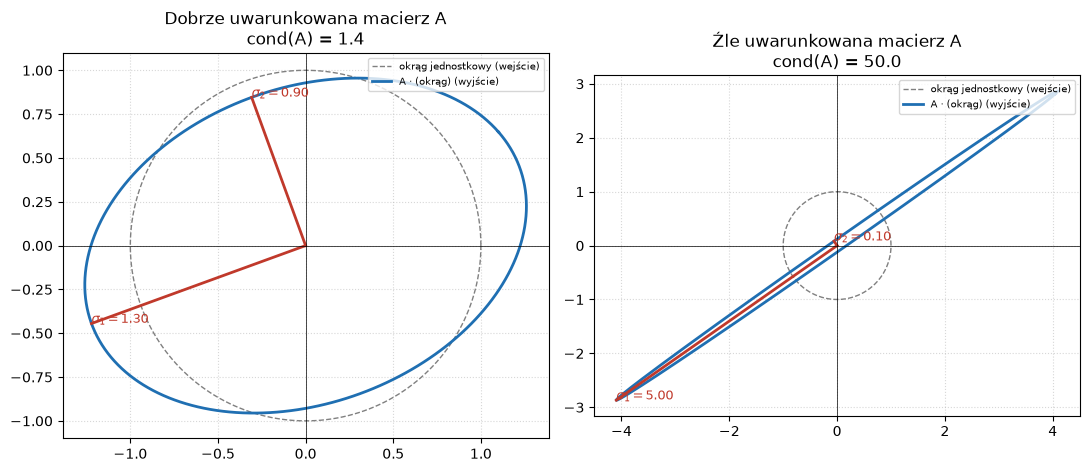

In [14]:
def macierz_o_zadanym_cond(sigma1, sigma2, kat_U_deg, kat_V_deg):
    # Buduje macierz 2x2 metoda odwrotna do SVD: A = U * diag(sigma1, sigma2) * V^T,
    # gdzie U i V to macierze obrotu o zadanych katach. Dzieki temu cond(A) = sigma1/sigma2
    # jest znane z gory, a nie przyblizone.
    def rot(deg):
        t = np.deg2rad(deg)
        return np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])
    U = rot(kat_U_deg)
    V = rot(kat_V_deg)
    S = np.diag([sigma1, sigma2])
    return U @ S @ V.T


def narysuj_elipse(A, ax, tytul):
    t = np.linspace(0, 2 * np.pi, 200)
    okrag = np.stack([np.cos(t), np.sin(t)])
    elipsa = A @ okrag

    U, S, _ = np.linalg.svd(A)
    cond = S[0] / S[1]

    ax.plot(okrag[0], okrag[1], '--', color='gray', linewidth=1, label='okrąg jednostkowy (wejście)')
    ax.plot(elipsa[0], elipsa[1], '-', color='#1f6fb2', linewidth=2, label='A · (okrąg) (wyjście)')
    for i in range(2):
        os_wektor = U[:, i] * S[i]
        ax.plot([0, os_wektor[0]], [0, os_wektor[1]], color='#c0392b', linewidth=2)
        ax.annotate(rf'$\sigma_{i+1}={S[i]:.2f}$', xy=os_wektor, color='#c0392b', fontsize=9)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(f'{tytul}\ncond(A) = {cond:.1f}')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, loc='upper right')


A_dobra = macierz_o_zadanym_cond(1.3, 0.9, kat_U_deg=20, kat_V_deg=-15)   # cond ~ 1.4
A_zla = macierz_o_zadanym_cond(5.0, 0.1, kat_U_deg=35, kat_V_deg=10)      # cond = 50

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
narysuj_elipse(A_dobra, axes[0], 'Dobrze uwarunkowana macierz A')
narysuj_elipse(A_zla, axes[1], 'Źle uwarunkowana macierz A')
plt.tight_layout()
plt.show()


## Demo 6: wpływ $\Delta A$ vs $\Delta b$ na błąd rozwiązania — który dominuje?

Do tej pory patrzyliśmy na **pełny** błąd rozwiązania w funkcji $cond(A)$, bez rozbicia go na źródła. Pełne oszacowanie z uwzględnieniem zaburzeń **obu** danych wejściowych (macierzy $A$ i wektora $b$) ma postać:

$$\frac{\|\Delta x\|}{\|x\|} \le \frac{cond(A)\cdot\frac{\|\Delta A\|}{\|A\|}}{1 - cond(A)\cdot\frac{\|\Delta A\|}{\|A\|}} + cond(A)\cdot\frac{\|\Delta b\|}{\|b\|}$$

W praktyce inżynierskiej **zwykle** to błąd danych wektora $b$ ma najistotniejsze znaczenie — często drugiego składnika ($\Delta A$) nawet się nie szacuje. **Nie** dlatego, że wzór matematycznie tak wymusza (dla małego $cond(A)\cdot\varepsilon$ oba składniki rosną podobnie), tylko dlatego, że w praktyce macierz $A$ jest zwykle znana **dokładniej** (mniejszy względny błąd) niż wektor $b$ (pomiary, szum). Pokazujemy realistyczny scenariusz: $\|\Delta A\|/\|A\| = 10^{-6}$ ($A$ znane niemal dokładnie) vs $\|\Delta b\|/\|b\| = 10^{-3}$ (typowy błąd pomiaru).

     cond(A)      wklad dA      wklad db           db/dA
    1.00e+01      1.00e-05      1.00e-02          1000.0
    1.00e+03      1.00e-03      1.00e+00           999.0
    1.00e+05      1.11e-01      1.00e+02           900.0
    9.00e+05      9.00e+00      9.00e+02           100.0


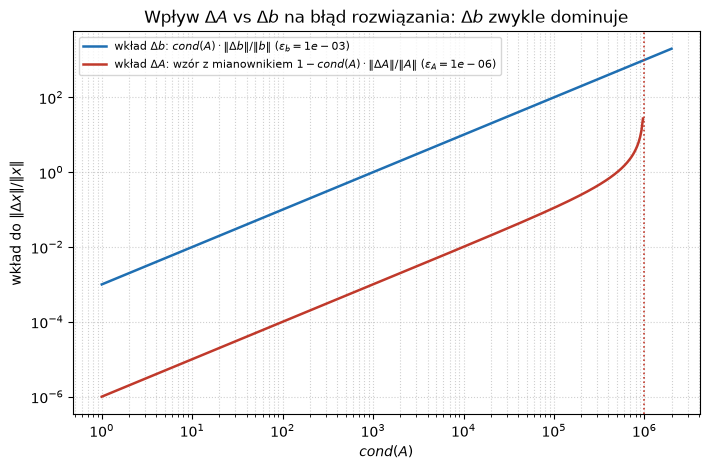

In [15]:
eps_A = 1e-6
eps_b = 1e-3
cond_zakres = np.logspace(0, 6.3, 400)

mianownik = 1 - cond_zakres * eps_A
wklad_A = np.where(mianownik > 1e-12, cond_zakres * eps_A / np.clip(mianownik, 1e-12, None), np.nan)
wklad_b = cond_zakres * eps_b

plt.figure(figsize=(7.2, 4.8))
plt.loglog(cond_zakres, wklad_b, '-', color='#1f6fb2', linewidth=1.8,
           label=fr'wkład $\Delta b$: $cond(A)\cdot\|\Delta b\|/\|b\|$ ($\varepsilon_b={eps_b:.0e}$)')
plt.loglog(cond_zakres, wklad_A, '-', color='#c0392b', linewidth=1.8,
           label=fr'wkład $\Delta A$: wzór z mianownikiem $1-cond(A)\cdot\|\Delta A\|/\|A\|$ ($\varepsilon_A={eps_A:.0e}$)')
plt.axvline(1/eps_A, color='#c0392b', linestyle=':', linewidth=1.2)
plt.xlabel(r'$cond(A)$')
plt.ylabel(r'wkład do $\|\Delta x\|/\|x\|$')
plt.title(r'Wpływ $\Delta A$ vs $\Delta b$ na błąd rozwiązania: $\Delta b$ zwykle dominuje')
plt.legend(fontsize=8, loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"{'cond(A)':>12}{'wklad dA':>14}{'wklad db':>14}{'db/dA':>16}")
for c_test in [10, 1e3, 1e5, 0.9/eps_A]:
    m = 1 - c_test * eps_A
    wa = c_test * eps_A / m if m > 1e-12 else np.inf
    wb = c_test * eps_b
    print(f"{c_test:12.2e}{wa:14.2e}{wb:14.2e}{wb/wa:16.1f}")

**Wniosek:** dla realistycznych $\varepsilon_A \ll \varepsilon_b$ ($A$ znane dużo dokładniej niż $b$), wkład $\Delta b$ **dominuje** nad wkładem $\Delta A$ w całej praktycznej skali $cond(A)$ — aż do punktu $cond(A)=1/\varepsilon_A$, gdzie sam wzór na $\Delta A$ eksploduje (mianownik dąży do zera — to matematyczny sygnał, że przy tak dużym $cond(A)$ nawet minimalna niepewność co do $A$ czyni cały wynik bezużytecznym, niezależnie od jakości $b$). To dlatego w praktyce raportuje się prawie zawsze **tylko** wkład $\Delta b$ — nie dlatego, że wkład $\Delta A$ jest matematycznie nieistotny, tylko dlatego, że w typowych zadaniach macierz $A$ (np. znane współczynniki układu) jest po prostu lepiej określona niż dane pomiarowe w $b$.

## Najważniejsze wnioski

- $cond(A)$ nie jest ciekawostką teoretyczną: to praktyczny **predyktor rzędu wielkości osiągalnej dokładności** rozwiązania, $\text{błąd}\approx cond(A)\cdot\varepsilon_{maszyny}$ — sprawdza się to w przybliżeniu dla zupełnie różnych rodzin macierzy i rozmiarów (Demo 2, Demo 3), więc można go liczyć *zamiast* rozwiązywania układu kilkoma metodami naraz. Stała mnożąca też zależy od struktury macierzy (tzw. growth factor eliminacji Gaussa — dokładnie 1 dla macierzy symetrycznych dodatnio określonych, jak Lehmera; łagodnie rosnący dla macierzy losowych), więc to oszacowanie rzędu wielkości, nie wzór ścisły.
- Utrata precyzji przy rosnącym $n$ jest nieunikniona, ale **tempo** jej narastania silnie zależy od charakteru danych (typu macierzy), a nie tylko od rozmiaru układu — te same $n$ mogą dawać $cond(A)$ różniące się o kilkanaście rzędów wielkości (Demo 4). Dlatego w praktyce liczy się $cond(A)$ dla konkretnego zadania, zamiast zakładać z góry bezpieczny/niebezpieczny rozmiar.
- Nazwa „uwarunkowanie” nie jest abstrakcyjna: $cond(A)$ to konkretny, geometryczny stosunek długości półosi elipsy, na jaką $A$ odwzorowuje okrąg jednostkowy (Demo 5).
- Duży $cond(A)$ = mocno spłaszczona elipsa = pewne kierunki danych wejściowych są niemal „niewidoczne” w wyniku przekształcenia, ale przy **odwracaniu** tego przekształcenia (czyli przy rozwiązywaniu układu) ten sam mały błąd w tych kierunkach zostaje silnie wzmocniony.
- LU i QR — mimo różnej ceny (patrz ILUSTR2) — podlegają temu samemu **rzędowi wielkości** ograniczenia $cond(A)\cdot\varepsilon_{maszyny}$ (Demo 2), ale nie są identyczne: na macierzy Lehmera LU jest konsekwentnie kilka razy **dokładniejsze** od QR, bo rozwiązanie przez QR wymaga dodatkowego kroku $Q^Tb$ po rozkładzie, a growth factor LU ($\rho_n$) jest tu dowiedziony równy $1$ (macierz symetryczna dodatnio określona) — LU działa w swoim najlepszym trybie, więc QR nie ma nic do "uratowania". Na macierzy **adwersarialnej** dla pivotingu ($\rho_n=2^{n-1}$, mimo małego $cond(A)$) sytuacja się odwraca: LU katastrofalnie zawodzi, a QR pozostaje na poziomie precyzji maszynowej — to prawdziwa, podręcznikowa przewaga QR, która ujawnia się jednak dopiero wtedy, gdy growth factor LU (a nie samo $cond(A)$) jest zły, nie na każdej źle uwarunkowanej macierzy. Użyte tu QR to **własna** implementacja Householdera — materiał opcjonalny (`Optional stuff/ZI_R_LIN_ILUSTR3_QR_LAPACK_OPTIONAL`) pokazuje, że wbudowana `np.linalg.qr` dorzuca do tego jeszcze dodatkowy, skokowy artefakt biblioteki LAPACK, która powyżej pewnego rozmiaru macierzy przełącza się na blokowany algorytm Householdera. Wniosek: o granicy osiągalnej dokładności decyduje nie tylko $cond(A)$, ale i to, jak dobrze dana metoda (i jej konkretna implementacja) radzi sobie akurat z tą macierzą.
- Pełne oszacowanie błędu ma **dwa** źródła: niepewność macierzy $A$ i niepewność wektora $b$ (Demo 6). W praktyce inżynierskiej to prawie zawsze wkład $\Delta b$ dominuje — nie z powodu samego wzoru, tylko dlatego, że $A$ bywa znane dużo dokładniej niż dane pomiarowe w $b$.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.linalg.solve(A, b)` | Rozwiązuje układ $Ax=b$ przez rozkład LU z pivotingiem |
| `qr_householder_wlasny(A)` (funkcja własna) | Rozkład QR metodą Householdera, nieblokowany ($A=QR$) — patrz komentarz w Demo 2, czemu własny zamiast `np.linalg.qr` |
| `scipy.linalg.solve_triangular(R, y)` | Rozwiązuje układ trójkątny (używane po rozkładzie QR) |
| `lehmer(n)` (funkcja własna) | Macierz Lehmera, $L_{i,j}=\min(i,j)/\max(i,j)$ — umiarkowanie źle uwarunkowana |
| `macierz_adwersarialna(n)` (funkcja własna) | Macierz z rho_n = 2^(n-1) przy małym cond(A) — pokazuje realną przewagę QR nad LU (Demo 2) |
| `scipy.linalg.hilbert(n)` | Macierz Hilberta, $h_{i,j}=1/(i+j-1)$ — ekstremalnie źle uwarunkowana |
| `np.linalg.cond(A)` | Współczynnik uwarunkowania $cond_2(A)=\sigma_{max}/\sigma_{min}$ |
| `np.linalg.svd(A)` | Rozkład według wartości osobliwych (SVD), $A=U\Sigma V^T$ |
| `scipy.linalg.lu(A)` | Rozkład LU z pivotingiem częściowym, $PA=LU$ -- używany tu do wyznaczenia growth factor |
| `np.finfo(np.float64).eps` | Precyzja maszynowa dla podwójnej precyzji |


## ĆWICZENIE

1. Rozszerz Demo 3 o trzecią rodzinę macierzy — np. macierze o zadanym z góry $cond(A)$ z funkcji `macierz_o_zadanym_cond` z Demo 5 (dla $n=2$, kolejno dla $cond(A)=10,100,1000,10000$) — i sprawdź, czy te punkty również układają się na tej samej prostej $cond(A)\cdot\varepsilon_{maszyny}$.
2. W Demo 5 zbuduj (funkcją `macierz_o_zadanym_cond`) macierz o zadanym z góry $cond(A)$, np. 1000, i sprawdź, że numerycznie zmierzony stosunek długości półosi rzeczywiście zgadza się z zadaną wartością.
3. Rozszerz Demo 2 o trzecią metodę: jawne odwrócenie macierzy (`x = np.linalg.inv(A) @ b`) i porównaj jej błąd z LU i QR dla macierzy Lehmera — czy jest gorsza, i jeśli tak, to dlaczego, skoro teoretycznie też powinna być rzędu $cond(A)\cdot\varepsilon$?
4. Demo 4 używa węzłów **równoodległych** dla macierzy Vandermonde'a. Zamień je na węzły Czebyszewa ($x_k=\cos\left(\frac{(2k-1)\pi}{2n}\right)$ dla $k=1..n$) i sprawdź, czy $cond(A)$ rośnie wolniej — to praktyczny powód, dla którego interpolacja wysokiego stopnia w praktyce unika węzłów równoodległych (patrz rozdział o interpolacji, zjawisko Rungego).
5. W Demo 6 zamień $\varepsilon_A=10^{-6}/\varepsilon_b=10^{-3}$ na sytuację **odwrotną** (np. $\varepsilon_A=10^{-2}$, $\varepsilon_b=10^{-6}$ — $A$ znane słabo, $b$ bardzo dokładnie). Który wkład dominuje teraz? Dla jakiego zakresu $cond(A)$ linie się przecinają?
